<a href="https://colab.research.google.com/github/EL-3raby/RFM-Customer-Segmentation/blob/main/RFM_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: using a fixed seed for reproducibility during testing
np.random.seed(42)

# generate mock transaction logs (approx 1k records)
n_transactions = 1000
customer_ids = np.random.randint(100, 500, n_transactions)
dates = [dt.datetime(2023, 1, 1) + dt.timedelta(days=np.random.randint(0, 365)) for _ in range(n_transactions)]
order_values = np.random.uniform(20, 500, n_transactions)

df_sales = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Order_Date': dates,
    'Order_Value': order_values
})

print(f"Loaded {len(df_sales)} transactions.")
display(df_sales.head())

Loaded 1000 transactions.


,Customer_ID,Order_Date,Order_Value
0,202,2023-01-28,436.770803
1,448,2023-07-21,369.041153
2,370,2023-02-08,376.499130
3,206,2023-09-30,224.236801
4,171,2023-08-19,186.048796


In [2]:
# set the reference date to 1 day after the last recorded transaction
snapshot_date = df_sales['Order_Date'].max() + dt.timedelta(days=1)

# aggregate metrics per customer for RFM
rfm = df_sales.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Customer_ID': 'count',
    'Order_Value': 'sum'
})

rfm.rename(columns={
    'Order_Date': 'Recency',
    'Customer_ID': 'Frequency',
    'Order_Value': 'MonetaryValue'
}, inplace=True)

# TODO: refine thresholds later based on actual business KPIs
def segment_customer(row):
    if row['Recency'] < 30 and row['Frequency'] > 5 and row['MonetaryValue'] > 1000:
        return 'VIP'
    elif row['Recency'] < 60 and row['Frequency'] >= 2:
        return 'Loyal'
    elif row['Recency'] > 180 and row['Frequency'] > 1:
        return 'At Risk'
    else:
        return 'New/Occasional'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

display(rfm.head(10))

,Recency,Frequency,MonetaryValue,Segment
Customer_ID,,,,
100,9,5,1611.200727,Loyal
101,22,3,629.351943,Loyal
102,54,1,143.651466,New/Occasional
103,274,2,508.073815,At Risk
104,27,5,898.847609,Loyal
105,81,2,516.866755,New/Occasional
106,14,2,320.106911,Loyal
107,71,3,704.013938,New/Occasional
108,47,3,721.220993,Loyal


/tmp/ipykernel_3123/1775925816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', palette='Set2', order=rfm['Segment'].value_counts().index)


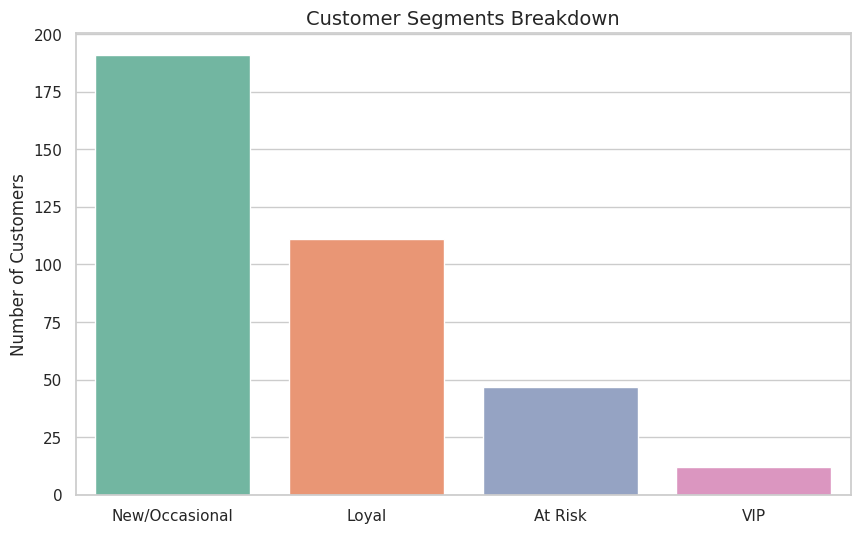

In [4]:
# viz 1: segment volume distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', palette='Set2', order=rfm['Segment'].value_counts().index)
plt.title('Customer Segments Breakdown', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.show()

# NOTE: check the ratio of 'At Risk' to 'VIP'. if risk is higher, marketing needs a pivot.

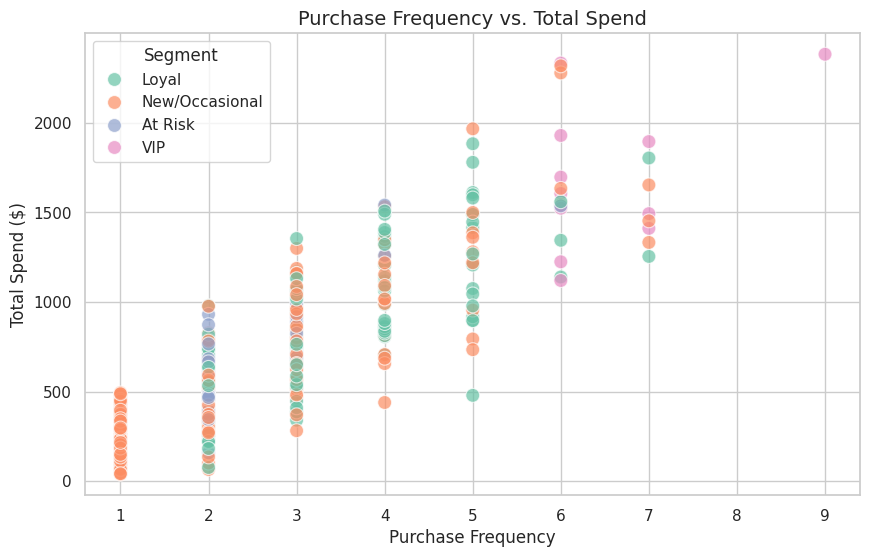

In [5]:
# viz 2: identify high-value clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='MonetaryValue', hue='Segment', palette='Set2', s=100, alpha=0.7)
plt.title('Purchase Frequency vs. Total Spend', fontsize=14)
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend ($)')
plt.legend(title='Segment')
plt.show()

# top right quadrant isolates our most valuable targets

/tmp/ipykernel_3123/4288277670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segment', y='MonetaryValue', palette='Set2')


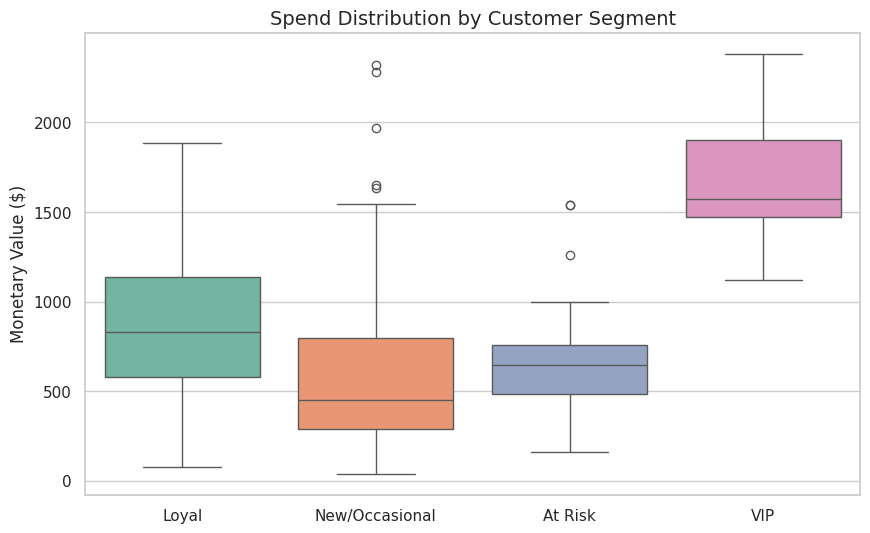

In [9]:
# viz 3: monetary variance and outliers per segment
plt.figure(figsize=(10, 6))
sns.boxplot(data=rfm, x='Segment', y='MonetaryValue', palette='Set2')
plt.title('Spend Distribution by Customer Segment', fontsize=14)
plt.ylabel('Monetary Value ($)')
plt.xlabel('')
plt.show()

# look for outliers (dots above boxes) in lower tiers. they are prime targets for immediate upsell.

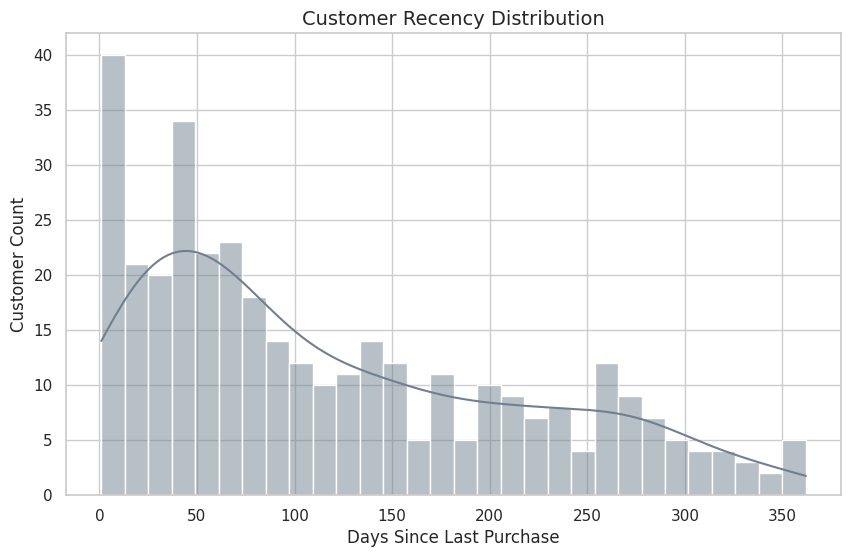

In [7]:
# viz 4: recency histogram (churn indicator)
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Recency'], bins=30, kde=True, color='slategray')
plt.title('Customer Recency Distribution', fontsize=14)
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Customer Count')
plt.show()

# long right tail indicates a growing base of churned users. investigate spike > 200 days.

In [10]:
# generate automated marketing action plan based on segment sizes
print("--- 🚀 Automated Marketing Action Plan ---")

vip_pct = (len(rfm[rfm['Segment'] == 'VIP']) / len(rfm)) * 100
risk_pct = (len(rfm[rfm['Segment'] == 'At Risk']) / len(rfm)) * 100

print(f"1. VIP Retention ({vip_pct:.1f}% of base):")
print("   -> Action: Send exclusive early-access emails for the next product launch.")

print(f"2. Churn Prevention ({risk_pct:.1f}% of base):")
print("   -> Action: Trigger automated win-back campaign with a 20% discount code.")

print("3. Loyal Upsell:")
print("   -> Action: Recommend bundled products based on their frequent purchases.")

# NOTE: these are baseline strategies. tweak according to current marketing budget.

--- 🚀 Automated Marketing Action Plan ---
1. VIP Retention (3.3% of base):
   -> Action: Send exclusive early-access emails for the next product launch.
2. Churn Prevention (13.0% of base):
   -> Action: Trigger automated win-back campaign with a 20% discount code.
3. Loyal Upsell:
   -> Action: Recommend bundled products based on their frequent purchases.


In [11]:
# export segmented list for CRM / marketing team use
export_filename = 'Customer_Segments_RFM.csv'

# sorting by monetary value to put the biggest spenders at the top
rfm_sorted = rfm.sort_values(by='MonetaryValue', ascending=False)
rfm_sorted.to_csv(export_filename)

print(f"File exported successfully: {export_filename}")
# ready to be imported into Mailchimp, HubSpot, or any CRM.

File exported successfully: Customer_Segments_RFM.csv
